# 02 Overtilpasning, kryssvalidering, regularisering og hyperparametere
*Data Mining & Analytics – Samling 2, dag 2*

Datasett: "diabetes" fra scikit-learn: 442 pasienter, 10 variabler (alder, kjønn, BMI, blodtrykk, 6 blodprøver), target = sykdomsprogresjon etter ett år.

In [9]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"      # fjerner en unødvendig advarsel fra joblib på Windows
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
rng = np.random.default_rng(42)

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, validation_curve
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X, y = load_diabetes(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape, X_test.shape)
X.describe().round(3).T[["mean", "std", "min", "max"]]

(331, 10) (111, 10)


,mean,std,min,max
age,-0.0,0.048,-0.107,0.111
sex,0.0,0.048,-0.045,0.051
bmi,-0.0,0.048,-0.090,0.171
bp,-0.0,0.048,-0.112,0.132
s1,-0.0,0.048,-0.127,0.154
s2,0.0,0.048,-0.116,0.199
s3,-0.0,0.048,-0.102,0.181
s4,-0.0,0.048,-0.076,0.185
s5,0.0,0.048,-0.126,0.134
s6,0.0,0.048,-0.138,0.136


## Trening, (validering) og test

* **Treningsdata**: tilpasse modellen 
* **Valideringsdata / kryssvalidering**: velge modell og hyperparametere 
* **Testdata**: en endelig vurdering

Testdata røres ikke før alle valg er tatt.

In [ ]:
rmse = lambda a, b: np.sqrt(mean_squared_error(a, b))
base = np.full(len(y_test), y_train.mean())
lr = LinearRegression().fit(X_train, y_train)
print(f"Baseline (gjennomsnitt):  RMSE test = {rmse(y_test, base):.1f}")
print(f"Lineær regresjon:         RMSE trening = {rmse(y_train, lr.predict(X_train)):.1f}, RMSE test = {rmse(y_test, lr.predict(X_test)):.1f},  R2 test = {r2_score(y_test, lr.predict(X_test)):.2f}")

Baseline (gjennomsnitt):  RMSE test = 74.9
Lineær regresjon:         RMSE trening = 53.9, test = 53.4,  R2 test = 0.48


## Overtilpasning: økende modellkompleksitet

Vi øker polynomgraden (flere og flere variabler) og ser på RMSE med 5-fold kryssvalidering.

In [ ]:
poly = [1, 2, 3]
min_liste = []
for p in poly:
    mod = make_pipeline(PolynomialFeatures(p, include_bias=False), StandardScaler(), LinearRegression())
    cv = cross_val_score(mod, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
    mod.fit(X_train, y_train)
    min_liste.append((p, mod.named_steps["linearregression"].coef_.size, rmse(y_train, mod.predict(X_train)), -cv.mean(), cv.std()))
tab = pd.DataFrame(min_liste, columns=["grad", "antall_parametere", "RMSE_trening", "RMSE_CV (val)", "CV_std (val)"]).round(1)
print(tab.to_string(index=False))

 grad  antall_parametere  RMSE_trening  RMSE_CV (val)  CV_std (val)
    1                 10          53.9           56.0           3.0
    2                 65          48.9           63.0           4.4
    3                285          23.3         7605.8        4541.1


Treningsfeilen synker hele tiden, men feilen på valideringsdata går opp igjen. Det er overtilpasning. 

## Regularisering: Ridge og Lasso

Ridge - Straffer store koeffisienter(L2)
Lasso (L1): kan sette koeffisienter eksakt til 0 - variabelseleksjon/eliminering

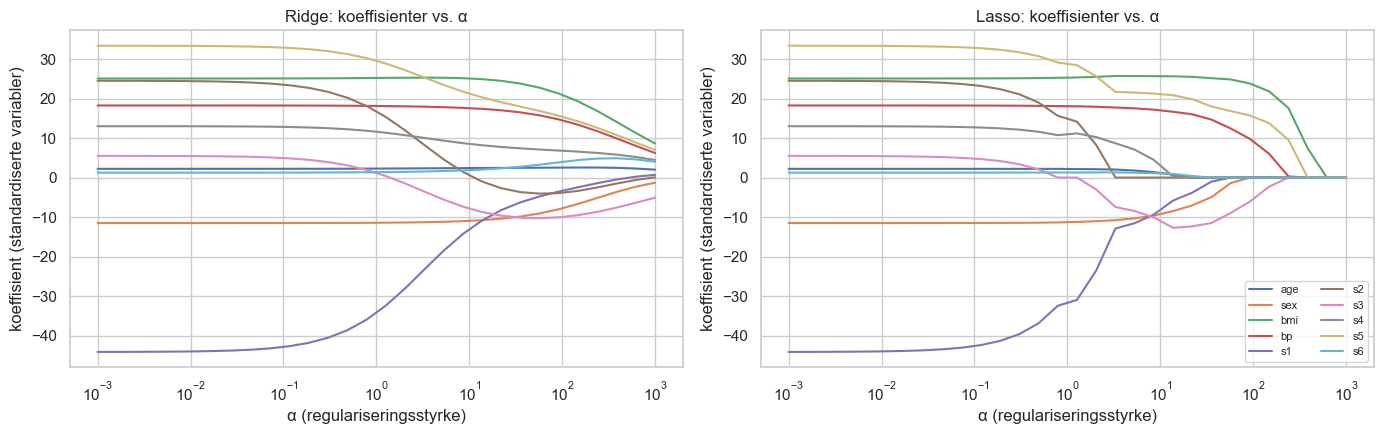

In [ ]:
alphaer = np.logspace(-3, 3, 30)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for navn, Modell, a in [("Ridge", Ridge, ax[0]), ("Lasso", Lasso, ax[1])]: # ridge og lasso er definert i importene
    koef = []
    for alp in alphaer:
        koef.append(Modell(alpha=alp if navn == "Ridge" else alp / 10, max_iter=20000).fit(StandardScaler().fit_transform(X_train), y_train).coef_)
    a.plot(alphaer, koef)
    a.set_xscale("log")
    a.set_title(f"{navn}: koeffisienter vs. α")
    a.set_xlabel("α (regulariseringsstyrke)")
    a.set_ylabel("koeffisient (standardiserte variabler)")
ax[1].legend(X.columns, ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Kryssvalidering og datalekkasje (data leakage)

Alle steg som *lærer* av data (skalering, imputering, variabelseleksjon, SMOTE …) må gjøres inne i kryssvalideringen og kun på treningsfoldene. Bruk f.eks `Pipeline`-funksjonen i sklearn.

Klassisk feil: tilpass og appliser skalerer på alle varaiblene før indeling i trening/test.

In [6]:
from sklearn.feature_selection import SelectKBest, f_regression
Xs = rng.normal(size=(100, 1000))
ys = rng.normal(size=100)         

# FEIL: seleksjon på alle data, deretter CV
X_sel = SelectKBest(f_regression, k=10).fit_transform(Xs, ys)
feil = cross_val_score(LinearRegression(), X_sel, ys, cv=5, scoring="r2").mean()

# RIKTIG: seleksjon inne i pipelinen (bare på treningsfoldene)
pipe = make_pipeline(SelectKBest(f_regression, k=10), LinearRegression())
riktig = cross_val_score(pipe, Xs, ys, cv=5, scoring="r2").mean()
print(f"R2 med lekkasje: {feil:.2f}  (ikke riktig)     R2 uten lekkasje: {riktig:.2f}  (riktig)")

R2 med lekkasje: 0.28  (ikke riktig)     R2 uten lekkasje: -0.43  (riktig)


## Hyperparametersøk med GridSearchCV

In [7]:
pipe = make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), Ridge())
grid = {"ridge__alpha": np.logspace(-1, 4, 12), "polynomialfeatures__degree": [1, 2]}
gs = GridSearchCV(pipe, grid, cv=KFold(5, shuffle=True, random_state=0), scoring="neg_root_mean_squared_error", n_jobs=1).fit(X_train, y_train)
print("Beste parametere:", gs.best_params_)
print("CV-RMSE:", (-gs.best_score_).round(1))

beste = gs.best_estimator_ 
print(f"\nTestsett:  RMSE = {rmse(y_test, beste.predict(X_test)):.1f},  MAE = {mean_absolute_error(y_test, beste.predict(X_test)):.1f},  R² = {r2_score(y_test, beste.predict(X_test)):.2f}")

Beste parametere: {'polynomialfeatures__degree': 1, 'ridge__alpha': np.float64(18.73817422860383)}
CV-RMSE: 55.5

Testsett:  RMSE = 53.1,  MAE = 41.5,  R² = 0.49


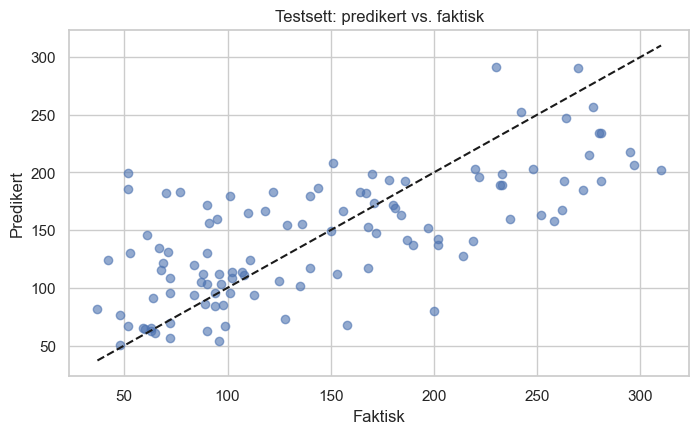

In [ ]:
plt.scatter(y_test, beste.predict(X_test), alpha=0.6)
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, "k--")
plt.xlabel("Faktisk")
plt.ylabel("Predikert")
plt.title("Testsett: Estimert vs. sann verdi")
plt.show()